# Gibbs MCEM for the network Ising-logistic model: Colab version

This version is meant for Google Colab, where the local `data/EllipticBitcoinDataset` folder from the project is not available. It downloads/processes the Elliptic Bitcoin dataset through PyTorch Geometric into `/content/data/EllipticBitcoinDataset`.


## Colab setup

Run this cell first in Colab. If `torch_geometric` is newly installed, restart the runtime if Colab asks you to.


In [ ]:
import importlib.util
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and importlib.util.find_spec("torch_geometric") is None:
    %pip install -q torch-geometric

if IN_COLAB and importlib.util.find_spec("sklearn") is None:
    %pip install -q scikit-learn


In [ ]:
from pathlib import Path
import warnings
import time

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import scipy.sparse as sp
import torch
from tqdm.auto import tqdm
from scipy.sparse.csgraph import connected_components
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*l1_ratio parameter is only used when penalty is.*")
warnings.filterwarnings("ignore", message=".*penalty.*deprecated.*")


In [ ]:
def set_random_seed(seed: int = 0):
    """Seed NumPy and torch; return a torch generator."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


In [ ]:
def default_elliptic_root() -> Path:
    """Use Colab storage when available; otherwise fall back to local project paths."""
    cwd = Path.cwd()
    candidates = []

    if Path("/content").exists():
        candidates.append(Path("/content") / "data" / "EllipticBitcoinDataset")

    candidates.extend([
        cwd / "data" / "EllipticBitcoinDataset",
        cwd.parent / "data" / "EllipticBitcoinDataset",
    ])

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def load_elliptic_from_pyg(root=None):
    """Load/download the PyG Elliptic Bitcoin dataset.

    PyG labels in this repository are encoded as:
    0 = licit, 1 = illicit, 2 = unknown.
    """
    from torch_geometric.datasets import EllipticBitcoinDataset

    root = default_elliptic_root() if root is None else Path(root)
    dataset = EllipticBitcoinDataset(root=str(root))
    data = dataset[0]

    X = data.x.float().cpu()
    edge_index = data.edge_index.long().cpu()
    y_raw = data.y.long().cpu()

    print(f"Loaded {root}")
    print(data)
    return X, edge_index, y_raw, data


In [ ]:
def normalize_labels(y_raw,
                     positive_values=(1,),
                     negative_values=(-1,),
                     unknown_values=(0, 2)):
    """Convert raw labels into {-1, +1, 0} where 0 means unobserved."""
    y = torch.as_tensor(y_raw).clone()
    y_pm1 = torch.zeros(y.numel(), dtype=torch.int8)

    for value in positive_values:
        y_pm1[y == value] = 1
    for value in negative_values:
        y_pm1[y == value] = -1
    for value in unknown_values:
        y_pm1[y == value] = 0

    covered = torch.zeros(y.numel(), dtype=torch.bool)
    for value in tuple(positive_values) + tuple(negative_values) + tuple(unknown_values):
        covered |= y == value
    if not bool(covered.all()):
        bad_values = torch.unique(y[~covered]).tolist()
        raise ValueError(f"Encountered uncovered label values: {bad_values}")

    observed_mask = y_pm1 != 0
    unlabeled_mask = ~observed_mask
    return y_pm1, observed_mask, unlabeled_mask


In [ ]:
def standardize_features(X):
    """Standardize features columnwise using torch tensors."""
    X = torch.as_tensor(X, dtype=torch.float32)
    mean = X.mean(dim=0, keepdim=True)
    scale = X.std(dim=0, unbiased=False, keepdim=True)
    scale = torch.where(scale == 0, torch.ones_like(scale), scale)
    X_std = (X - mean) / scale
    scaler = {"mean": mean, "scale": scale}
    return X_std, scaler


In [ ]:
def build_symmetric_adjacency(num_nodes: int,
                              edge_index,
                              remove_self_loops: bool = True):
    """Build one symmetric CSR adjacency matrix from PyG edge_index.

    PyG stores the graph as directed edge pairs. For the Ising term we use the
    undirected version, represented as a sparse CSR matrix for fast slicing and
    Gibbs neighbor updates.
    """
    edge_index = torch.as_tensor(edge_index, dtype=torch.long).cpu()
    if edge_index.ndim != 2:
        raise ValueError("edge_index must be a 2D array/tensor.")

    if edge_index.shape[0] == 2:
        src = edge_index[0].numpy()
        dst = edge_index[1].numpy()
    elif edge_index.shape[1] == 2:
        src = edge_index[:, 0].numpy()
        dst = edge_index[:, 1].numpy()
    else:
        raise ValueError("edge_index must have shape (2, m) or (m, 2).")

    data = np.ones(len(src), dtype=np.float64)
    A = sp.coo_matrix((data, (src, dst)), shape=(num_nodes, num_nodes))
    A = (A + A.T).tocsr()

    if remove_self_loops:
        A.setdiag(0)
        A.eliminate_zeros()

    A.data[:] = 1.0
    return A


def undirected_edges_from_adjacency(A):
    """Return each undirected edge once as a torch LongTensor with shape (2, E)."""
    upper = sp.triu(A, k=1).tocoo()
    edges = np.vstack((upper.row, upper.col))
    return torch.as_tensor(edges, dtype=torch.long)


def edge_quadratic_sum(sigma, undirected_edges):
    """Compute sum_{(i,j) in E} sigma_i sigma_j by summing over edges once."""
    sigma = torch.as_tensor(sigma, dtype=torch.float32)
    edges = torch.as_tensor(undirected_edges, dtype=torch.long)
    return torch.sum(sigma[edges[0]] * sigma[edges[1]])


In [ ]:
def initialize_parameters_via_logistic(X,
                                       y_pm1,
                                       init_lasso_C: float = 1.0,
                                       max_iter: int = 1000,
                                       random_state: int = 0):
    """Initialize beta, gamma, and missing labels with lasso-logistic regression.

    init_lasso_C is sklearn's inverse L1 regularization strength: smaller
    values mean a stronger lasso penalty.
    """
    X_t = torch.as_tensor(X, dtype=torch.float32)
    y_t = torch.as_tensor(y_pm1, dtype=torch.int8)
    X_np = X_t.numpy()
    y_np = y_t.numpy()

    observed_mask = y_np != 0
    if observed_mask.sum() == 0:
        raise ValueError("No observed labels found.")

    y_binary = (y_np[observed_mask] == 1).astype(int)
    if np.unique(y_binary).size < 2:
        raise ValueError("Observed labels contain only one class; logistic initialization is not possible.")

    model = LogisticRegression(
        penalty="elasticnet",
        l1_ratio=1.0,
        C=init_lasso_C,
        fit_intercept=False,
        solver="saga",
        max_iter=max_iter,
        tol=1e-3,
        random_state=random_state,
    )
    model.fit(X_np[observed_mask], y_binary)

    logits = model.decision_function(X_np)
    init_proba = 1.0 / (1.0 + np.exp(-logits))
    gamma0 = model.coef_.reshape(-1) / 4.0
    beta0 = 0.0

    sigma0 = np.where(init_proba >= 0.5, 1, -1).astype(np.int8)
    sigma0[observed_mask] = y_pm1[observed_mask]

    return beta0, gamma0, sigma0, init_proba, model


In [ ]:
def compute_local_field(node_index: int, sigma, A, X, beta: float, gamma):
    """Compute the local field
        h_i = beta * sum_{j ~ i} sigma_j + 2 X_i^T gamma
    for a single node.
    """
    row_start = A.indptr[node_index]
    row_end = A.indptr[node_index + 1]
    neighbors = A.indices[row_start:row_end]
    neighbor_sum = sigma[neighbors].sum()
    return beta * neighbor_sum + 2.0 * float(X[node_index] @ gamma)


In [ ]:
def gibbs_sweep_inplace(sigma,
                       neighbor_sum,
                       unlabeled_idx,
                       A,
                       beta: float,
                       linear_term,
                       rng):
    """Perform one in-place Gibbs sweep over the unlabeled nodes.

    `linear_term = 2 * X @ gamma` is constant within an E-step, so it is
    precomputed once in `draw_posterior_samples` instead of recomputed every
    sweep.
    """
    order = rng.permutation(unlabeled_idx)

    for i in order:
        h_i = beta * neighbor_sum[i] + linear_term[i]
        p_plus = 1.0 / (1.0 + np.exp(-2.0 * h_i))
        new_val = 1 if rng.random() < p_plus else -1
        old_val = sigma[i]

        if new_val != old_val:
            delta = new_val - old_val
            sigma[i] = new_val
            neighbors = A.indices[A.indptr[i] : A.indptr[i + 1]]
            neighbor_sum[neighbors] += delta

    return sigma, neighbor_sum


In [ ]:
def draw_posterior_samples(sigma_start,
                           observed_mask,
                           y_pm1,
                           A,
                           X,
                           beta: float,
                           gamma,
                           num_burnin: int = 50,
                           num_samples: int = 20,
                           thinning: int = 5,
                           seed: int = 0,
                           show_progress: bool = True,
                           progress_desc: str = "Gibbs",
                           trace_nodes=None,
                           record_diagnostics: bool = True):
    """Draw posterior samples of the unlabeled spins by Gibbs sampling."""
    rng = np.random.default_rng(seed)

    sigma = np.asarray(sigma_start, dtype=np.int8).copy()
    sigma[observed_mask] = y_pm1[observed_mask]

    unlabeled_idx = np.flatnonzero(~observed_mask)
    neighbor_sum = np.asarray(A @ sigma, dtype=np.float64).reshape(-1)
    linear_term = 2.0 * (X @ gamma)

    trace_nodes = None if trace_nodes is None else np.asarray(trace_nodes, dtype=int)
    if not record_diagnostics:
        trace_nodes = None
    trace_values = []
    spin_vector_trace = []

    total_sweeps = num_burnin + num_samples * thinning
    sweep_bar = tqdm(total=total_sweeps, desc=progress_desc, leave=False, disable=not show_progress)

    for _ in range(num_burnin):
        sigma, neighbor_sum = gibbs_sweep_inplace(
            sigma=sigma,
            neighbor_sum=neighbor_sum,
            unlabeled_idx=unlabeled_idx,
            A=A,
            beta=beta,
            linear_term=linear_term,
            rng=rng,
        )
        sigma[observed_mask] = y_pm1[observed_mask]
        if record_diagnostics:
            spin_vector_trace.append(sigma[unlabeled_idx].copy())
        if trace_nodes is not None and trace_nodes.size > 0:
            trace_values.append(sigma[trace_nodes].copy())
        sweep_bar.update(1)

    samples = np.empty((num_samples, sigma.shape[0]), dtype=np.int8)
    for sample_id in range(num_samples):
        for _ in range(thinning):
            sigma, neighbor_sum = gibbs_sweep_inplace(
                sigma=sigma,
                neighbor_sum=neighbor_sum,
                unlabeled_idx=unlabeled_idx,
                A=A,
                beta=beta,
                linear_term=linear_term,
                rng=rng,
            )
            sigma[observed_mask] = y_pm1[observed_mask]
            if record_diagnostics:
                spin_vector_trace.append(sigma[unlabeled_idx].copy())
            if trace_nodes is not None and trace_nodes.size > 0:
                trace_values.append(sigma[trace_nodes].copy())
            sweep_bar.update(1)

        samples[sample_id] = sigma

    sweep_bar.close()
    trace_values = np.asarray(trace_values, dtype=np.int8) if trace_values else None
    spin_vector_trace = np.asarray(spin_vector_trace, dtype=np.int8) if record_diagnostics else None
    return samples, sigma.copy(), trace_values, spin_vector_trace


In [ ]:
def estimate_posterior_means(samples, observed_mask, y_pm1):
    """Estimate posterior means E[sigma_i | observed data] from Gibbs samples.

    Parameters
    ----------
    samples : ndarray, shape (M, n)
    observed_mask : ndarray[bool], shape (n,)
    y_pm1 : ndarray, shape (n,)

    Returns
    -------
    posterior_mean : ndarray, shape (n,)
        Monte Carlo estimate of E[sigma_i | observed data].
    posterior_prob_plus : ndarray, shape (n,)
        Monte Carlo estimate of P(sigma_i = +1 | observed data).
    """
    posterior_mean = samples.mean(axis=0)
    posterior_mean = posterior_mean.astype(float)
    posterior_mean[observed_mask] = y_pm1[observed_mask]
    posterior_prob_plus = 0.5 * (posterior_mean + 1.0)
    return posterior_mean, posterior_prob_plus


In [ ]:
def build_mc_logistic_pseudolikelihood_design(samples, undirected_edges, X):
    """Build conditional-logistic rows using torch edge accumulation.

    Each undirected edge contributes once to each endpoint via `index_add_`,
    avoiding one sparse matrix-vector multiply per Gibbs sample.
    """
    with torch.no_grad():
        samples_t = torch.as_tensor(samples, dtype=torch.float32)
        X_t = torch.as_tensor(X, dtype=torch.float32)
        edges = torch.as_tensor(undirected_edges, dtype=torch.long)

        if samples_t.ndim != 2:
            raise ValueError("samples must have shape (num_samples, num_nodes).")

        num_samples, num_nodes = samples_t.shape
        src, dst = edges[0], edges[1]

        neighbor_sum = torch.zeros((num_samples, num_nodes), dtype=torch.float32)
        neighbor_sum.index_add_(1, src, samples_t[:, dst])
        neighbor_sum.index_add_(1, dst, samples_t[:, src])

        design_t = torch.empty((num_samples * num_nodes, X_t.shape[1] + 1), dtype=torch.float32)
        design_t[:, 0] = (2.0 * neighbor_sum).reshape(-1)
        feature_block = 4.0 * X_t
        for sample_id in range(num_samples):
            start = sample_id * num_nodes
            end = start + num_nodes
            design_t[start:end, 1:] = feature_block
        target_t = (samples_t.reshape(-1) == 1).to(torch.int64)

    return np.ascontiguousarray(design_t.numpy()), target_t.numpy()


In [ ]:
def m_step_optimize(samples,
                    undirected_edges,
                    X,
                    beta_init: float,
                    gamma_init,
                    lasso_C: float = 1.0,
                    beta_nonnegative: bool = True,
                    maxiter: int = 500,
                    seed: int = 0):
    """Run the M-step with lasso-logistic regression on MC pseudolikelihood rows.

    lasso_C is sklearn's inverse regularization strength: smaller values mean
    a stronger L1/lasso penalty.
    """
    design, target = build_mc_logistic_pseudolikelihood_design(samples=samples, undirected_edges=undirected_edges, X=X)

    model = LogisticRegression(
        penalty="elasticnet",
        l1_ratio=1.0,
        C=lasso_C,
        fit_intercept=False,
        solver="saga",
        max_iter=maxiter,
        tol=1e-3,
        random_state=seed,
    )
    model.fit(design, target)

    coef = model.coef_.reshape(-1)
    beta_hat = float(coef[0])
    gamma_hat = np.asarray(coef[1:], dtype=float)

    # Keep the homophily parameter nonnegative when requested. If the fitted
    # conditional logistic model wants a negative beta, project it to zero.
    if beta_nonnegative and beta_hat < 0.0:
        beta_hat = 0.0

    return beta_hat, gamma_hat, model


In [ ]:
def predict_labels_from_posterior_mean(posterior_mean):
    """Convert posterior means into hard labels and probabilities.

    Returns
    -------
    hard_labels : ndarray, shape (n,)
        Values in {-1, +1}.
    prob_plus : ndarray, shape (n,)
        Values in [0, 1].
    """
    posterior_mean = np.asarray(posterior_mean, dtype=float)
    hard_labels = np.where(posterior_mean >= 0.0, 1, -1).astype(np.int8)
    prob_plus = 0.5 * (posterior_mean + 1.0)
    return hard_labels, prob_plus


In [ ]:
def make_known_label_validation_split(y_pm1_full, validation_fraction=0.2, seed=305):
    """Mask a stratified fraction of known labels for held-out evaluation."""
    y = torch.as_tensor(y_pm1_full, dtype=torch.int8)
    y_train = y.clone()
    validation_mask = torch.zeros(y.numel(), dtype=torch.bool)

    generator = torch.Generator().manual_seed(seed)
    for label in (-1, 1):
        class_idx = torch.nonzero(y == label, as_tuple=False).flatten()
        if class_idx.numel() <= 1:
            continue

        num_validation = int(round(validation_fraction * class_idx.numel()))
        num_validation = max(1, num_validation)
        num_validation = min(num_validation, class_idx.numel() - 1)

        shuffled = class_idx[torch.randperm(class_idx.numel(), generator=generator)]
        validation_idx = shuffled[:num_validation]
        validation_mask[validation_idx] = True

    y_train[validation_mask] = 0
    train_observed_mask = y_train != 0
    if torch.unique(y_train[train_observed_mask]).numel() < 2:
        raise ValueError("Training split has only one observed class. Lower validation_fraction or use a larger component.")
    if torch.unique(y[validation_mask]).numel() < 2:
        print("Warning: validation split has only one class, so ROC AUC will be undefined.")

    return y_train, validation_mask, train_observed_mask


def evaluate_heldout_known_labels(results, y_pm1_full, validation_mask):
    """Evaluate predictions on known labels that were masked before fitting."""
    y_true_spin = torch.as_tensor(y_pm1_full, dtype=torch.int8)[validation_mask].cpu().numpy()
    if y_true_spin.size == 0:
        raise ValueError("No held-out validation labels were selected.")

    y_true = (y_true_spin == 1).astype(int)
    y_pred_spin = np.asarray(results["hard_labels"])[validation_mask.cpu().numpy()]
    y_pred = (y_pred_spin == 1).astype(int)
    y_score = np.asarray(results["posterior_prob_plus"])[validation_mask.cpu().numpy()]

    metrics = {
        "num_validation": int(y_true.size),
        "num_validation_licit": int((y_true == 0).sum()),
        "num_validation_illicit": int((y_true == 1).sum()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_illicit": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_illicit": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_illicit": float(f1_score(y_true, y_pred, zero_division=0)),
        "confusion_matrix_licit_illicit": confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist(),
    }

    if np.unique(y_true).size == 2:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_score))
        metrics["average_precision"] = float(average_precision_score(y_true, y_score))
    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan

    return metrics


In [ ]:
def run_gibbs_mcem(y_pm1,
                   X,
                   A,
                   undirected_edges=None,
                   num_em_steps: int = 10,
                   num_burnin: int = 50,
                   num_samples: int = 20,
                   thinning: int = 5,
                   lasso_C: float = 1.0,
                   init_lasso_C: float = 1.0,
                   beta_nonnegative: bool = True,
                   optimizer_maxiter: int = 200,
                   seed: int = 0,
                   show_progress: bool = True,
                   trace_nodes=None,
                   record_mcmc_diagnostics: bool = True,
                   beta_init=None,
                   gamma_init=None,
                   sigma_init=None,
                   initial_history_offset: int = 0):
    """Run Gibbs-MCEM with a pseudolikelihood M-step.

    Parameters
    ----------
    y_pm1 : ndarray, shape (n,)
        Labels in {-1, 0, +1}; 0 means missing.
    X : ndarray, shape (n, p)
    A : csr_matrix, shape (n, n)
    num_em_steps : int
    num_burnin : int
    num_samples : int
    thinning : int
    lasso_C : float
        Inverse L1 regularization strength for the lasso-logistic pseudolikelihood M-step.
    init_lasso_C : float
        Inverse L1 regularization strength for the initialization lasso-logistic fit.
    beta_nonnegative : bool
    optimizer_maxiter : int
    seed : int
    show_progress : bool

    Returns
    -------
    results : dict
        Dictionary containing fitted parameters, posterior summaries, and
        iteration history.
    """
    y_pm1_t = torch.as_tensor(y_pm1, dtype=torch.int8)
    X_t = torch.as_tensor(X, dtype=torch.float32)
    y_pm1 = y_pm1_t.numpy()
    X_np = X_t.numpy()

    if undirected_edges is None:
        undirected_edges = undirected_edges_from_adjacency(A)

    observed_mask = y_pm1 != 0
    unlabeled_mask = ~observed_mask

    if beta_init is None or gamma_init is None or sigma_init is None:
        beta, gamma, sigma_current, init_proba, init_model = initialize_parameters_via_logistic(
            X=X_np,
            y_pm1=y_pm1,
            init_lasso_C=init_lasso_C,
            random_state=seed,
        )
    else:
        beta = float(beta_init)
        gamma = np.asarray(gamma_init, dtype=float).copy()
        sigma_current = np.asarray(sigma_init, dtype=np.int8).copy()
        sigma_current[observed_mask] = y_pm1[observed_mask]
        init_proba = None
        init_model = None

    history = []
    diagnostics = {"trace_nodes": None, "em_traces": [], "spin_vector_traces": []}
    if record_mcmc_diagnostics and trace_nodes is not None:
        trace_nodes = np.asarray(trace_nodes, dtype=int)
        diagnostics["trace_nodes"] = trace_nodes.copy()

    posterior_mean = sigma_current.astype(float)
    posterior_prob_plus = 0.5 * (posterior_mean + 1.0)

    em_iter = tqdm(range(num_em_steps), desc="MCEM", disable=not show_progress)
    for t in em_iter:
        samples, sigma_last, trace_values, spin_vector_trace = draw_posterior_samples(
            sigma_start=sigma_current,
            observed_mask=observed_mask,
            y_pm1=y_pm1,
            A=A,
            X=X_np,
            beta=beta,
            gamma=gamma,
            num_burnin=num_burnin,
            num_samples=num_samples,
            thinning=thinning,
            seed=seed + 1000 * (t + 1),
            show_progress=show_progress,
            progress_desc=f"Gibbs {t + 1}/{num_em_steps}",
            trace_nodes=trace_nodes,
            record_diagnostics=record_mcmc_diagnostics,
        )

        if spin_vector_trace is not None:
            diagnostics["spin_vector_traces"].append(spin_vector_trace)
        if trace_values is not None:
            diagnostics["em_traces"].append(trace_values)

        posterior_mean, posterior_prob_plus = estimate_posterior_means(
            samples=samples,
            observed_mask=observed_mask,
            y_pm1=y_pm1,
        )

        beta_new, gamma_new, m_step_model = m_step_optimize(
            samples=samples,
            undirected_edges=undirected_edges,
            X=X_t,
            beta_init=beta,
            gamma_init=gamma,
            lasso_C=lasso_C,
            beta_nonnegative=beta_nonnegative,
            maxiter=optimizer_maxiter,
            seed=seed + 2000 * (t + 1),
        )

        sigma_current = np.where(posterior_mean >= 0.0, 1, -1).astype(np.int8)
        sigma_current[observed_mask] = y_pm1[observed_mask]

        m_step_iterations = int(np.max(m_step_model.n_iter_))
        m_step_converged = m_step_iterations < optimizer_maxiter

        history.append({
            "iteration": initial_history_offset + t + 1,
            "beta": beta_new,
            "gamma_l2_norm": float(np.linalg.norm(gamma_new)),
            "gamma": gamma_new.copy(),
            "m_step_converged": bool(m_step_converged),
            "m_step_iterations": m_step_iterations,
            "m_step_message": "sklearn lasso LogisticRegression fit",
            "mean_posterior_prob_unlabeled": (
                float(posterior_prob_plus[unlabeled_mask].mean())
                if unlabeled_mask.any() else np.nan
            ),
        })

        if show_progress:
            em_iter.set_postfix({"beta": f"{beta_new:.3g}", "mstep_iter": m_step_iterations})

        beta, gamma = beta_new, gamma_new

    hard_labels, hard_prob_plus = predict_labels_from_posterior_mean(posterior_mean)

    results = {
        "beta": beta,
        "gamma": gamma,
        "posterior_mean": posterior_mean,
        "posterior_prob_plus": posterior_prob_plus,
        "hard_labels": hard_labels,
        "observed_mask": observed_mask,
        "unlabeled_mask": unlabeled_mask,
        "history": history,
        "initial_logistic_prob_plus": init_proba,
        "initial_logistic_model": init_model,
        "last_complete_state": sigma_last,
        "diagnostics": diagnostics,
    }
    return results


## Warm-Start Helper

Use this to continue MCEM from an existing `results` object instead of restarting from `beta = 0`. This does not use `init_lasso_C`; it starts directly from the previous `beta`, `gamma`, and latent spin state.


In [ ]:
def continue_gibbs_mcem(previous_results,
                        y_pm1,
                        X,
                        A,
                        undirected_edges=None,
                        num_em_steps: int = 5,
                        num_burnin: int = 50,
                        num_samples: int = 20,
                        thinning: int = 5,
                        lasso_C: float = 1.0,
                        beta_nonnegative: bool = True,
                        optimizer_maxiter: int = 200,
                        seed: int = 0,
                        show_progress: bool = True,
                        trace_nodes=None,
                        record_mcmc_diagnostics: bool = True):
    """Continue MCEM from the final beta/gamma/spin state in previous_results."""
    previous_history = previous_results.get("history", [])
    history_offset = int(previous_history[-1]["iteration"]) if previous_history else 0

    continued = run_gibbs_mcem(
        y_pm1=y_pm1,
        X=X,
        A=A,
        undirected_edges=undirected_edges,
        num_em_steps=num_em_steps,
        num_burnin=num_burnin,
        num_samples=num_samples,
        thinning=thinning,
        lasso_C=lasso_C,
        beta_nonnegative=beta_nonnegative,
        optimizer_maxiter=optimizer_maxiter,
        seed=seed,
        show_progress=show_progress,
        trace_nodes=trace_nodes,
        record_mcmc_diagnostics=record_mcmc_diagnostics,
        beta_init=previous_results["beta"],
        gamma_init=previous_results["gamma"],
        sigma_init=previous_results["last_complete_state"],
        initial_history_offset=history_offset,
    )

    continued["history"] = previous_history + continued["history"]
    previous_diagnostics = previous_results.get("diagnostics", {})
    new_diagnostics = continued.get("diagnostics", {})
    continued["diagnostics"] = {
        "trace_nodes": new_diagnostics.get("trace_nodes", previous_diagnostics.get("trace_nodes")),
        "em_traces": previous_diagnostics.get("em_traces", []) + new_diagnostics.get("em_traces", []),
        "spin_vector_traces": previous_diagnostics.get("spin_vector_traces", []) + new_diagnostics.get("spin_vector_traces", []),
    }
    return continued


## Component Helpers

These cells define helper functions for selecting connected components and optional connected samples. They do not run the model.


In [ ]:
def component_nodes_from_adjacency(A_full, component_rank=1):
    """Return node ids for one connected component, ordered by component size."""
    n_components, component_labels = connected_components(
        A_full,
        directed=False,
        return_labels=True,
    )
    component_sizes = np.bincount(component_labels, minlength=n_components)
    ordered_components = np.argsort(component_sizes)[::-1]

    if not 1 <= component_rank <= len(ordered_components):
        raise ValueError(f"component_rank must be between 1 and {len(ordered_components)}.")

    component_id = ordered_components[component_rank - 1]
    nodes = np.flatnonzero(component_labels == component_id)
    return nodes.astype(int), int(component_sizes[component_id])


def cap_component_with_bfs(A_full, component_nodes, y_raw, max_nodes):
    """Optionally take a connected BFS sample from a component using the CSR adjacency."""
    if max_nodes is None or max_nodes >= len(component_nodes):
        return np.array(component_nodes, dtype=int)

    component_set = set(component_nodes.tolist())
    y_np = torch.as_tensor(y_raw).numpy()
    illicit_nodes = component_nodes[y_np[component_nodes] == 1]
    seed = int(illicit_nodes.min()) if len(illicit_nodes) else int(component_nodes.min())

    sampled = []
    seen = {seed}
    queue = [seed]
    while queue and len(sampled) < max_nodes:
        current = queue.pop(0)
        sampled.append(current)
        neighbors = A_full.indices[A_full.indptr[current] : A_full.indptr[current + 1]]
        for neighbor in sorted(neighbors.tolist()):
            if neighbor in component_set and neighbor not in seen:
                seen.add(neighbor)
                queue.append(neighbor)
            if len(sampled) + len(queue) >= max_nodes:
                break

    return np.array(sampled, dtype=int)


## Plotting Helper

This defines plotting only. The actual plot call is separated below so you can skip it during model runs.


In [ ]:
def plot_original_vs_predicted_network(
    A_component,
    y_raw_component,
    results,
    output_path=None,
    max_plot_nodes=None,
    seed=305,
):
    """Plot original vs predicted labels, optionally on a connected plot sample.

    NetworkX spring layout is expensive on thousands of nodes. This samples only
    for visualization; it does not change the model fit or benchmark.
    """
    plt.close("all")
    plot_nodes = np.arange(A_component.shape[0])
    if max_plot_nodes is not None and A_component.shape[0] > max_plot_nodes:
        plot_nodes = cap_component_with_bfs(
            A_full=A_component,
            component_nodes=plot_nodes,
            y_raw=y_raw_component,
            max_nodes=max_plot_nodes,
        )
        A_plot = A_component[plot_nodes][:, plot_nodes].copy()
        y_plot_tensor = torch.as_tensor(y_raw_component)[torch.as_tensor(plot_nodes, dtype=torch.long)]
        hard_labels = np.asarray(results["hard_labels"])[plot_nodes]
        subtitle_suffix = f"{len(plot_nodes):,} node visualization sample"
    else:
        A_plot = A_component
        y_plot_tensor = torch.as_tensor(y_raw_component)
        hard_labels = np.asarray(results["hard_labels"])
        subtitle_suffix = f"{A_component.shape[0]:,} nodes"

    graph = nx.from_scipy_sparse_array(A_plot)
    pos = nx.spring_layout(graph, seed=seed, k=0.06, iterations=40)

    original_colors = {0: "#2a9d8f", 1: "#e63946", 2: "#8d99ae"}
    predicted_colors = {-1: "#2a9d8f", 1: "#e63946"}

    y_plot = y_plot_tensor.cpu().tolist()
    original_node_colors = [original_colors[int(label)] for label in y_plot]
    predicted_node_colors = [predicted_colors[int(label)] for label in hard_labels]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    panels = [
        (axes[0], original_node_colors, "Original labels", f"gray = unknown; {subtitle_suffix}"),
        (axes[1], predicted_node_colors, "Predicted labels", f"posterior hard labels; {subtitle_suffix}"),
    ]

    node_size = max(3, min(12, 18000 / graph.number_of_nodes()))
    for ax, colors, title, subtitle in panels:
        nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.08, width=0.35, edge_color="#4a4e69")
        nx.draw_networkx_nodes(
            graph,
            pos,
            ax=ax,
            node_color=colors,
            node_size=node_size,
            linewidths=0,
        )
        ax.set_title(title + chr(10) + subtitle, fontsize=13)
        ax.axis("off")

    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w", label="licit", markerfacecolor="#2a9d8f", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", label="illicit", markerfacecolor="#e63946", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", label="unknown original", markerfacecolor="#8d99ae", markersize=8),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=220, bbox_inches="tight")
        print(f"Saved figure to {output_path}")

    return fig, axes


## MCMC Diagnostic Helpers

These functions plot autocorrelation for the Gibbs chain state: the vector of unknown spins. The raw overlap is `E[<sigma_t, sigma_{t+lag}> / n_unknown]`; the centered curve subtracts each coordinate's empirical mean first.


In [ ]:
def choose_trace_nodes(y_pm1_train, max_nodes=6, seed=305):
    """Choose a small, reproducible set of currently unobserved nodes to monitor."""
    missing_idx = np.flatnonzero(torch.as_tensor(y_pm1_train).cpu().numpy() == 0)
    if missing_idx.size == 0 or max_nodes <= 0:
        return np.array([], dtype=int)
    rng = np.random.default_rng(seed)
    size = min(max_nodes, missing_idx.size)
    return np.sort(rng.choice(missing_idx, size=size, replace=False))


def autocorrelation_1d(values, max_lag=40):
    """Compute simple normalized autocorrelation for lags 0..max_lag."""
    x = np.asarray(values, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    if denom == 0:
        out = np.zeros(max_lag + 1, dtype=float)
        out[0] = 1.0
        return out
    max_lag = min(max_lag, len(x) - 1)
    acf = np.empty(max_lag + 1, dtype=float)
    for lag in range(max_lag + 1):
        acf[lag] = np.dot(x[: len(x) - lag], x[lag:]) / denom
    return acf






def spin_vector_overlap_autocorrelation(spin_trace, max_lag=40):
    """Compute raw C(lag) = mean_t <sigma_t, sigma_{t+lag}> / n.

    `spin_trace` should contain the Gibbs chain state only: the unknown spins,
    not the fixed observed labels.
    """
    trace = np.asarray(spin_trace, dtype=np.float32)
    if trace.ndim != 2:
        raise ValueError("spin_trace must have shape (num_sweeps, num_unknown_nodes).")
    num_sweeps, _ = trace.shape
    max_lag = min(max_lag, num_sweeps - 1)
    overlaps = np.empty(max_lag + 1, dtype=float)
    for lag in range(max_lag + 1):
        products = trace[: num_sweeps - lag] * trace[lag:]
        overlaps[lag] = float(products.mean())
    return overlaps


def centered_spin_vector_autocorrelation(spin_trace, max_lag=40):
    """Compute centered normalized vector autocorrelation.

    This removes the marginal mean of each coordinate, so independent draws from
    a biased posterior decay toward 0 rather than toward a positive baseline.
    """
    trace = np.asarray(spin_trace, dtype=np.float32)
    centered = trace - trace.mean(axis=0, keepdims=True)
    denom = float(np.mean(centered * centered))
    num_sweeps, _ = centered.shape
    max_lag = min(max_lag, num_sweeps - 1)
    acf = np.empty(max_lag + 1, dtype=float)
    if denom == 0.0:
        acf.fill(0.0)
        acf[0] = 1.0
        return acf
    for lag in range(max_lag + 1):
        acf[lag] = float(np.mean(centered[: num_sweeps - lag] * centered[lag:]) / denom)
    return acf


def plot_mcmc_trace_autocorrelation(results, max_lag=40, em_iteration=-1, include_node_traces=False):
    """Plot full unknown-spin-vector overlap diagnostics.

    Raw overlap:
        C_raw(lag) = E_t[<sigma_t, sigma_{t+lag}> / n_unknown].
    Centered overlap subtracts each coordinate's empirical mean first, which is
    often easier to read as a mixing diagnostic.
    """
    diagnostics = results.get("diagnostics", {})
    spin_vector_traces = diagnostics.get("spin_vector_traces", [])

    if len(spin_vector_traces) == 0:
        print("No full spin-vector diagnostics were recorded. Rerun MCEM first.")
        return None

    spin_trace = np.asarray(spin_vector_traces[em_iteration], dtype=np.int8)
    raw_overlap = spin_vector_overlap_autocorrelation(spin_trace, max_lag=max_lag)
    centered_overlap = centered_spin_vector_autocorrelation(spin_trace, max_lag=max_lag)
    sweep_index = np.arange(spin_trace.shape[0])

    trace_nodes = diagnostics.get("trace_nodes")
    em_traces = diagnostics.get("em_traces", [])
    show_nodes = include_node_traces and trace_nodes is not None and len(trace_nodes) > 0 and len(em_traces) > 0
    node_rows = len(trace_nodes) if show_nodes else 0
    total_rows = 1 + node_rows

    plt.close("all")
    fig, axes = plt.subplots(total_rows, 2, figsize=(13, 3.0 * total_rows), constrained_layout=True)
    if total_rows == 1:
        axes = np.array([axes])

    axes[0, 0].plot(sweep_index, spin_trace.mean(axis=1), linewidth=1.2)
    axes[0, 0].set_title("Unknown spin vector summary: mean(sigma_t)")
    axes[0, 0].set_xlabel("Gibbs sweep")
    axes[0, 0].set_ylabel("mean unknown spin")

    lags = np.arange(len(raw_overlap))
    axes[0, 1].plot(lags, raw_overlap, marker="o", label="raw overlap")
    axes[0, 1].plot(lags, centered_overlap, marker="o", label="centered normalized")
    axes[0, 1].axhline(0.0, color="black", linewidth=0.8, alpha=0.4)
    axes[0, 1].set_ylim(-1.05, 1.05)
    axes[0, 1].set_title("Unknown spin-vector autocorrelation")
    axes[0, 1].set_xlabel("lag")
    axes[0, 1].set_ylabel("overlap / autocorrelation")
    axes[0, 1].legend(frameon=False)

    if show_nodes:
        traces = em_traces[em_iteration]
        for row, node in enumerate(trace_nodes, start=1):
            series = traces[:, row - 1]
            acf = autocorrelation_1d(series, max_lag=max_lag)
            axes[row, 0].plot(series, linewidth=1.0)
            axes[row, 0].set_ylim(-1.2, 1.2)
            axes[row, 0].set_title(f"Node {int(node)} trace")
            axes[row, 0].set_xlabel("Gibbs sweep")
            axes[row, 0].set_ylabel("spin")

            axes[row, 1].stem(np.arange(len(acf)), acf, basefmt=" ")
            axes[row, 1].set_ylim(-1.05, 1.05)
            axes[row, 1].set_title(f"Node {int(node)} autocorrelation")
            axes[row, 1].set_xlabel("lag")
            axes[row, 1].set_ylabel("ACF")

    return fig


## EM Parameter Path Helper

This plots how `beta` and `gamma` evolve across MCEM iterations.


In [ ]:
def plot_em_parameter_paths(results, top_gamma_features=10):
    """Plot beta_t, ||gamma_t||_2, and selected gamma coefficient paths."""
    history = results.get("history", [])
    if len(history) == 0:
        print("No EM history found. Run MCEM first.")
        return None

    iterations = np.array([row["iteration"] for row in history])
    beta_path = np.array([row["beta"] for row in history], dtype=float)
    gamma_norm_path = np.array([row["gamma_l2_norm"] for row in history], dtype=float)
    gamma_path = np.vstack([row["gamma"] for row in history if "gamma" in row])

    if gamma_path.shape[0] != len(history):
        gamma_path = None

    if gamma_path is None or gamma_path.shape[1] == 0 or top_gamma_features <= 0:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    else:
        fig, axes = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)

    axes[0].plot(iterations, beta_path, marker="o")
    axes[0].set_title("Beta path")
    axes[0].set_xlabel("EM iteration")
    axes[0].set_ylabel("beta")

    axes[1].plot(iterations, gamma_norm_path, marker="o", color="#6a4c93")
    axes[1].set_title("Gamma norm path")
    axes[1].set_xlabel("EM iteration")
    axes[1].set_ylabel("||gamma||_2")

    if gamma_path is not None and gamma_path.shape[1] > 0 and top_gamma_features > 0:
        final_abs = np.abs(gamma_path[-1])
        feature_ids = np.argsort(final_abs)[-min(top_gamma_features, gamma_path.shape[1]):][::-1]
        for feature_id in feature_ids:
            axes[2].plot(iterations, gamma_path[:, feature_id], marker="o", linewidth=1.2, label=f"x{feature_id}")
        axes[2].set_title(f"Top {len(feature_ids)} gamma coefficients")
        axes[2].set_xlabel("EM iteration")
        axes[2].set_ylabel("gamma_j")
        axes[2].legend(frameon=False, fontsize=8, ncol=2)

    return fig


## Run Configuration

Change these values before running the data-prep and MCEM cells.


In [266]:
MAX_NODES = None          # None = entire selected component; use 500/2000 for smoke tests.
NUM_FEATURES = 94         # Elliptic local features. Use 165 for all PyG features.
COMPONENT_RANK = 1        # 1 = largest connected component.
VALIDATION_FRACTION = 0.2

NUM_EM_STEPS = 20
NUM_BURNIN = 100
NUM_SAMPLES = 100
THINNING = 3
LASSO_C = 0.1
INIT_LASSO_C = 0.1
BETA_NONNEGATIVE = True
OPTIMIZER_MAXITER = 1000
SEED = 305

SHOW_PROGRESS = True
RECORD_MCMC_DIAGNOSTICS = False
RUN_PLOT = True
PLOT_MAX_NODES = 2000
TRACE_NUM_NODES = 0
TRACE_MAX_LAG = 40
TRACE_INCLUDE_NODE_PLOTS = False

TOP_GAMMA_FEATURES = 10

CONTINUE_EM_STEPS = 10


## Load And Prepare Component

This loads the dataset, builds/slices the undirected adjacency, masks held-out known labels for validation, and standardizes features.


In [ ]:
timings = {}
t0_total = time.perf_counter()

t0 = time.perf_counter()
X, edge_index, y_raw, data_obj = load_elliptic_from_pyg()
timings["load_data_sec"] = time.perf_counter() - t0

# PyG gives directed edge_index, not an undirected adjacency matrix. Build the
# symmetric CSR adjacency once, then use it both for components and Gibbs/MCEM.
t0 = time.perf_counter()
A_full = build_symmetric_adjacency(num_nodes=X.shape[0], edge_index=edge_index)
component_nodes, full_component_size = component_nodes_from_adjacency(
    A_full,
    component_rank=COMPONENT_RANK,
)
nodes = cap_component_with_bfs(
    A_full=A_full,
    component_nodes=component_nodes,
    y_raw=y_raw,
    max_nodes=MAX_NODES,
)

nodes_t = torch.as_tensor(nodes, dtype=torch.long)
X_component = X[nodes_t, :NUM_FEATURES]
y_raw_component = y_raw[nodes_t]
A = A_full[nodes][:, nodes].copy()
A.eliminate_zeros()
undirected_edges_component = undirected_edges_from_adjacency(A)
timings["graph_setup_sec"] = time.perf_counter() - t0

# Correct PyG Elliptic label mapping for this repo:
# illicit -> +1, licit -> -1, unknown -> 0/missing.
y_pm1, observed_mask, unlabeled_mask = normalize_labels(
    y_raw_component,
    positive_values=(1,),
    negative_values=(0,),
    unknown_values=(2,),
)

if torch.unique(y_pm1[observed_mask]).numel() < 2:
    raise ValueError("Selected component has only one observed class. Choose a larger/different component.")

y_pm1_train, validation_mask, train_observed_mask = make_known_label_validation_split(
    y_pm1,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
)

trace_nodes = (
    choose_trace_nodes(y_pm1_train, max_nodes=TRACE_NUM_NODES, seed=SEED)
    if RECORD_MCMC_DIAGNOSTICS else np.array([], dtype=int)
)
X_std, scaler = standardize_features(X_component)

print(f"Component rank: {COMPONENT_RANK}")
print(f"Full component size: {full_component_size:,}")
print(f"Nodes used: {X_std.shape[0]:,}")
print(f"Undirected Ising edges: {A.nnz // 2:,}")
print(
    "Labels:",
    f"licit={int((y_pm1 == -1).sum()):,}",
    f"illicit={int((y_pm1 == 1).sum()):,}",
    f"unknown={int((y_pm1 == 0).sum()):,}",
)
print("Trace nodes:", trace_nodes.tolist())
print(
    "Held-out known labels:",
    f"total={int(validation_mask.sum()):,}",
    f"licit={int(((y_pm1 == -1) & validation_mask).sum()):,}",
    f"illicit={int(((y_pm1 == 1) & validation_mask).sum()):,}",
)


## Run MCEM

This is the main model-fitting cell. Rerun this after changing MCEM hyperparameters.


In [ ]:
t0 = time.perf_counter()
results = run_gibbs_mcem(
    y_pm1=y_pm1_train,
    X=X_std,
    A=A,
    undirected_edges=undirected_edges_component,
    num_em_steps=NUM_EM_STEPS,
    num_burnin=NUM_BURNIN,
    num_samples=NUM_SAMPLES,
    thinning=THINNING,
    lasso_C=LASSO_C,
    init_lasso_C=INIT_LASSO_C,
    beta_nonnegative=BETA_NONNEGATIVE,
    optimizer_maxiter=OPTIMIZER_MAXITER,
    seed=SEED,
    show_progress=SHOW_PROGRESS,
    trace_nodes=trace_nodes,
    record_mcmc_diagnostics=RECORD_MCMC_DIAGNOSTICS,
)
timings["mcem_sec"] = time.perf_counter() - t0

print("beta_hat =", results["beta"])
print("history =", results["history"])


## Continue MCEM From Current Estimates

Run this cell if the beta/gamma paths have not stabilized and you want to continue from the current `results` instead of restarting.


In [267]:
t0 = time.perf_counter()
results = continue_gibbs_mcem(
    previous_results=results,
    y_pm1=y_pm1_train,
    X=X_std,
    A=A,
    undirected_edges=undirected_edges_component,
    num_em_steps=CONTINUE_EM_STEPS,
    num_burnin=NUM_BURNIN,
    num_samples=NUM_SAMPLES,
    thinning=THINNING,
    lasso_C=LASSO_C,
    beta_nonnegative=BETA_NONNEGATIVE,
    optimizer_maxiter=OPTIMIZER_MAXITER,
    seed=SEED + 100_000 + len(results["history"]),
    show_progress=SHOW_PROGRESS,
    trace_nodes=trace_nodes,
    record_mcmc_diagnostics=RECORD_MCMC_DIAGNOSTICS,
)
timings["continue_mcem_sec"] = time.perf_counter() - t0

print("continued beta_hat =", results["beta"])
print("total EM iterations =", len(results["history"]))
print("last history row =", results["history"][-1])


MCEM:   0%|          | 0/10 [00:00<?, ?it/s]

Gibbs 1/10:   0%|          | 0/400 [00:00<?, ?it/s]

Gibbs 2/10:   0%|          | 0/400 [00:00<?, ?it/s]

Gibbs 3/10:   0%|          | 0/400 [00:00<?, ?it/s]

Gibbs 4/10:   0%|          | 0/400 [00:00<?, ?it/s]

...

Gibbs 7/10:   0%|          | 0/400 [00:00<?, ?it/s]

Gibbs 8/10:   0%|          | 0/400 [00:00<?, ?it/s]

Gibbs 9/10:   0%|          | 0/400 [00:00<?, ?it/s]

Gibbs 10/10:   0%|          | 0/400 [00:00<?, ?it/s]

continued beta_hat = 1.010697603225708
total EM iterations = 40
last history row = {'iteration': 40, 'beta': 1.010697603225708, 'gamma_l2_norm': 0.33279003874531726, 'gamma': array([ 7.87839852e-03,  6.48714155e-02,  6.26517534e-02, -8.79078582e-02,
        3.12500000e-02, -6.99589550e-02, -3.82853113e-02,  1.27993030e-02,
        7.49397045e-03, -2.98169684e-02,  1.09445294e-02,  1.14474287e-02,
       -7.81359244e-03,  3.12500000e-02,  1.05671333e-02,  3.12730521e-02,
       -3.07780993e-03, -7.81250373e-03, -4.40755114e-03,  3.15212123e-02,
        1.49728702e-02, -1.50228047e-03, -7.91819859e-03,  1.51289217e-02,
        1.80094852e-03,  1.06413485e-02,  2.15959270e-02, -1.50070479e-03,
       -7.91819859e-03,  1.51305934e-02,  1.80081755e-03,  3.78464558e-03,
        2.15949733e-02,  4.23680991e-03, -7.41619710e-03, -1.78997330e-02,
       -1.46262175e-06,  3.13120075e-02, -5.15055470e-02, -3.12500000e-02,
       -6.60330802e-03, -3.65754869e-03, -3.91510874e-03,  2.23588757e-02,


## EM Parameter Paths

Run this after `Run MCEM` to inspect beta and gamma changes across EM iterations.


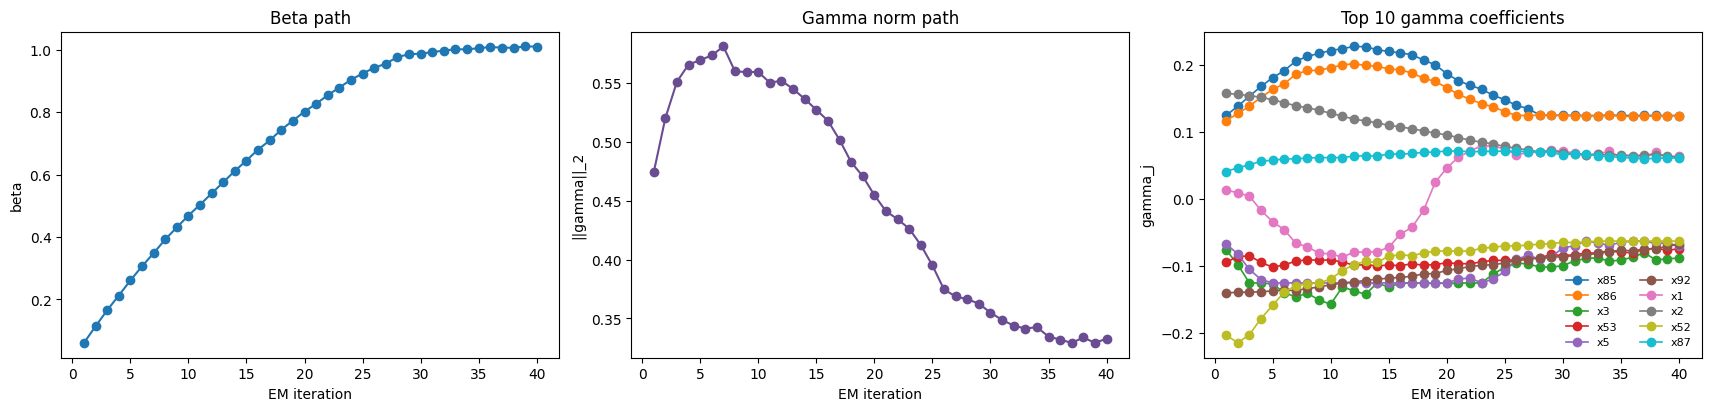

In [268]:
fig = plot_em_parameter_paths(results, top_gamma_features=TOP_GAMMA_FEATURES)
if fig is not None:
    display(fig)
    plt.show()


## Held-Out Benchmark

This evaluates only on known labels that were masked before fitting.


In [269]:
t0 = time.perf_counter()
heldout_metrics = evaluate_heldout_known_labels(
    results=results,
    y_pm1_full=y_pm1,
    validation_mask=validation_mask,
)
timings["evaluation_sec"] = time.perf_counter() - t0
timings["total_before_plot_sec"] = time.perf_counter() - t0_total

print("heldout_metrics =", heldout_metrics)
print("timings_sec =", {key: round(value, 3) for key, value in timings.items()})


heldout_metrics = {'num_validation': 429, 'num_validation_licit': 426, 'num_validation_illicit': 3, 'accuracy': 0.9557109557109557, 'balanced_accuracy': 0.6467136150234741, 'precision_illicit': 0.05555555555555555, 'recall_illicit': 0.3333333333333333, 'f1_illicit': 0.09523809523809523, 'confusion_matrix_licit_illicit': [[409, 17], [2, 1]], 'roc_auc': 0.8552425665101722, 'average_precision': 0.047614950299514056}
timings_sec = {'load_data_sec': 0.735, 'graph_setup_sec': 0.132, 'mcem_sec': 1299.082, 'evaluation_sec': 0.022, 'total_before_plot_sec': 5834.265, 'plot_sec': 16.756, 'continue_mcem_sec': 935.176}


## MCMC Trace And Autocorrelation

Use this after `Run MCEM` to inspect mixing of the unknown spin vector. The plot shows both raw vector overlap and centered normalized vector autocorrelation.


In [ ]:
if not RECORD_MCMC_DIAGNOSTICS:
    print("MCMC diagnostics were not recorded. Set RECORD_MCMC_DIAGNOSTICS = True and rerun MCEM to plot them.")
else:
    fig = plot_mcmc_trace_autocorrelation(
        results,
        max_lag=TRACE_MAX_LAG,
        em_iteration=-1,
        include_node_traces=TRACE_INCLUDE_NODE_PLOTS,
    )
    if fig is not None:
        display(fig)
        plt.show()


## Original Vs Predicted Network

This optional visualization cell uses the fitted `results`. It can sample nodes for faster plotting without changing model estimates.


Saved figure to /content/figures/ising_original_vs_predicted_component.png
plot_time_sec = 18.54


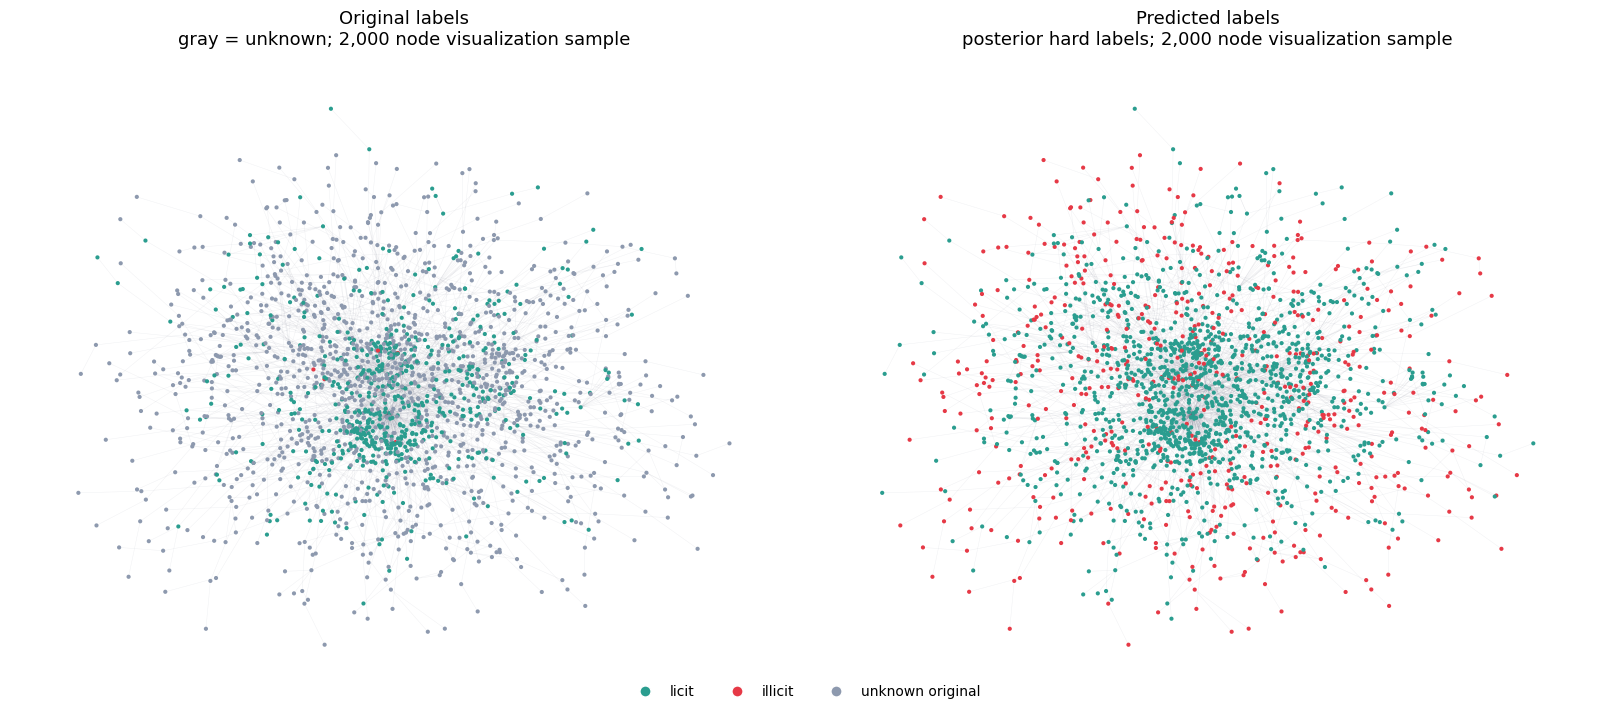

In [270]:
if RUN_PLOT:
    t0 = time.perf_counter()
    fig, axes = plot_original_vs_predicted_network(
        A_component=A,
        y_raw_component=y_raw_component,
        results=results,
        output_path=default_elliptic_root().parents[1] / "figures" / "ising_original_vs_predicted_component.png",
        max_plot_nodes=PLOT_MAX_NODES,
    )
    plot_time = time.perf_counter() - t0
    if "timings" in globals():
        timings["plot_sec"] = plot_time
    print("plot_time_sec =", round(plot_time, 3))
    display(fig)
    plt.show()
else:
    print("Skipping network plot because RUN_PLOT = False")


In [271]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
from pathlib import Path

SAVE_DIR = Path("/content/drive/MyDrive/stat305c_ising_runs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

save_path = SAVE_DIR / "ising_mcem_results.pkl"

payload = {
    "results": results,
    "heldout_metrics": heldout_metrics,
    "timings": timings,
    "nodes": nodes,
    "y_pm1": y_pm1,
    "y_pm1_train": y_pm1_train,
    "validation_mask": validation_mask,
    "config": {
        "MAX_NODES": MAX_NODES,
        "NUM_FEATURES": NUM_FEATURES,
        "COMPONENT_RANK": COMPONENT_RANK,
        "VALIDATION_FRACTION": VALIDATION_FRACTION,
        "NUM_EM_STEPS": NUM_EM_STEPS,
        "NUM_BURNIN": NUM_BURNIN,
        "NUM_SAMPLES": NUM_SAMPLES,
        "THINNING": THINNING,
        "LASSO_C": LASSO_C,
        "INIT_LASSO_C": INIT_LASSO_C,
        "BETA_NONNEGATIVE": BETA_NONNEGATIVE,
        "OPTIMIZER_MAXITER": OPTIMIZER_MAXITER,
        "SEED": SEED,
    },
}

with open(save_path, "wb") as f:
    pickle.dump(payload, f)

print("Saved to", save_path)


Mounted at /content/drive
Saved to /content/drive/MyDrive/stat305c_ising_runs/ising_mcem_results.pkl


In [ ]:
import pickle

with open("/content/drive/MyDrive/stat305c_ising_runs/ising_mcem_results.pkl", "rb") as f:
    payload = pickle.load(f)

results = payload["results"]
heldout_metrics = payload["heldout_metrics"]
timings = payload["timings"]


## Function summary

- `default_elliptic_root()`: chooses where the Elliptic dataset should live. In Colab it uses `/content/data/EllipticBitcoinDataset`; locally it falls back to the project `data/` folder.
- `load_elliptic_from_pyg()`: downloads/loads the PyG Elliptic dataset and returns torch tensors for node features `X`, raw directed `edge_index`, raw labels `y_raw`, plus the PyG `data` object.
- `normalize_labels()`: maps PyG labels to Ising spins: illicit `1 -> +1`, licit `0 -> -1`, unknown `2 -> 0`.
- `standardize_features()`: column-standardizes the selected feature matrix with torch before logistic/lasso fitting.
- `build_symmetric_adjacency()`: converts PyG's directed `edge_index` into one symmetric sparse CSR adjacency for the undirected Ising term.
- `undirected_edges_from_adjacency()`: extracts each undirected edge once as a torch edge list for faster edge-sum computations.
- `edge_quadratic_sum()`: computes the Ising edge statistic as `sum sigma_i sigma_j` over undirected edges once.
- `initialize_parameters_via_logistic()`: fits a lasso-logistic model on observed labels to initialize missing spins before MCEM starts.
- `compute_local_field()`: computes one node's Ising conditional field from neighbors and covariates.
- `gibbs_sweep_inplace()`: performs one Gibbs sweep over unknown-label nodes while keeping observed labels fixed; the covariate term is precomputed once per E-step.
- `draw_posterior_samples()`: runs burn-in, thinning, and sample collection for the E-step.
- `estimate_posterior_means()`: converts Gibbs samples into posterior means and illicit probabilities.
- `build_mc_logistic_pseudolikelihood_design()`: turns Gibbs samples into logistic-regression rows using torch edge accumulation instead of repeated sparse matrix-vector products.
- `m_step_optimize()`: fits the lasso-logistic pseudolikelihood M-step and returns updated `beta` and `gamma`.
- `predict_labels_from_posterior_mean()`: converts posterior means into hard licit/illicit predictions.
- `make_known_label_validation_split()`: holds out a stratified fraction of known labels and masks them during fitting.
- `evaluate_heldout_known_labels()`: reports accuracy, balanced accuracy, precision, recall, F1, ROC AUC, average precision, and confusion matrix on held-out known labels.
- `run_gibbs_mcem()`: orchestrates the full MCEM loop: initialize, Gibbs E-step, lasso M-step, progress bars, optional diagnostics, and history tracking.
- `component_nodes_from_adjacency()`: finds connected components directly from the sparse symmetric adjacency.
- `cap_component_with_bfs()`: optionally takes a connected BFS sample from the chosen component for quick smoke tests.
- `choose_trace_nodes()`: selects a small set of unobserved nodes for MCMC diagnostics.
- `autocorrelation_1d()`: computes simple lag autocorrelations for a trace.
- `spin_vector_overlap_autocorrelation()`: computes raw `E[<sigma_t, sigma_{t+lag}> / n_unknown]` from the unknown-spin Gibbs trace.
- `centered_spin_vector_autocorrelation()`: computes the centered normalized version, which should decay toward 0 when mixing.
- `plot_mcmc_trace_autocorrelation()`: plots raw and centered unknown-spin vector autocorrelation; optional node traces are available.
- `plot_original_vs_predicted_network()`: plots original labels and model predictions side by side, with optional node sampling so layout does not dominate runtime.


## Practical remarks

1. This is a **Monte Carlo EM with a lasso-logistic pseudolikelihood M-step**, not exact full-likelihood EM.

2. On a graph as large as Elliptic, start with small values such as:
   - `num_em_steps = 3 to 5`
   - `num_burnin = 10 to 30`
   - `num_samples = 5 to 15`
   - `thinning = 2 to 5`

3. If you want an intercept, append a column of ones to `X` before standardization, or standardize first and then append the ones column.

4. PyG stores the Elliptic graph as `edge_index`, not as an undirected adjacency matrix. The notebook builds one symmetric CSR adjacency once, then slices it for the selected component.

5. The Gibbs sweep uses an in-place update of the vector `A @ sigma`, so each sweep is roughly linear in the number of edges.

6. Set `RUN_PLOT = False` or lower `PLOT_MAX_NODES` when benchmarking model runtime; NetworkX layout can be slower than the model on large components.

7. Set `SHOW_PROGRESS = False` if progress bars interfere with timing output or notebook rendering.

8. For full-size runs, keep `RECORD_MCMC_DIAGNOSTICS = False` to avoid storing every Gibbs spin vector. Turn it on only for smaller diagnostic runs.


In [ ]:
import numpy as np
import json
from pathlib import Path

save_dir = Path("checkpoints")
save_dir.mkdir(exist_ok=True)

beta_hat = results["beta"]
gamma_hat = results["gamma"]

np.savez(
    save_dir / "ising_params_current.npz",
    beta=beta_hat,
    gamma=gamma_hat
)

print("Saved beta and gamma to", save_dir / "ising_params_current.npz")

In [ ]:
print(beta_hat)
print(gamma_hat)